The code models polaritons formed when a cavity photon couples to a microscopically calculated, Coulomb-interacting multilevel electron–hole system, going beyond Jaynes–Cummings’ single two-level emitter.

In [2]:
!pip install SciencePlots
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

# Jaynes-Cunnings anticrossing

In this section we verify the anticrossing in the Jaynes Cunnings model, to later compare it with the results of the exact model

Dominant bare-state character at omega_c = 4.00 GHz (omega_q = 5.0 GHz, detuning = -1.00 GHz):
  E[0] =  0.0000 GHz  <-  |0,g>     (excitation manifold N=0)
  E[1] =  6.2268 GHz  <-  |1,g>     (excitation manifold N=1)
  E[2] =  7.2268 GHz  <-  |0,e>     (excitation manifold N=1)
  E[3] = 13.4536 GHz  <-  |1,e>     (excitation manifold N=2)


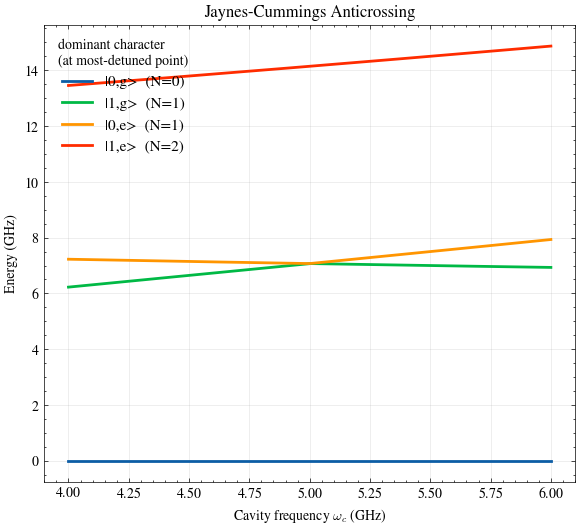

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# -----------------------------
# Parameters
# -----------------------------
omega_q = 5.0      # qubit frequency (GHz)
g = 5           # coupling strength (GHz)

wc_list = np.linspace(4.0, 6.0, 300)   # cavity frequency sweep

Nphot = 2          # photon number truncation (>=3 so |1,e> can hybridize with |2,g>)

# -----------------------------
# Operators
# -----------------------------
I2 = np.eye(2)
IN = np.eye(Nphot)

a = np.zeros((Nphot, Nphot))
for n in range(1, Nphot):
    a[n-1, n] = np.sqrt(n)
adag = a.T

sz = np.array([[1, 0], [0, -1]])
sp = np.array([[0, 1], [0, 0]])
sm = np.array([[0, 0], [1, 0]])

# basis ordering: kron(photon, qubit)
A = np.kron(a, I2)
Adag = np.kron(adag, I2)
Sz = np.kron(IN, sz)
Sp = np.kron(IN, sp)
Sm = np.kron(IN, sm)

dim = Nphot * 2

# -----------------------------
# -----------------------------
qubit_labels = ['g', 'e']
basis_labels = np.array([f"|{n},{q}>" for n in range(Nphot) for q in qubit_labels])
excitation_number = np.array([n + (1 if q == 'e' else 0)
                               for n in range(Nphot) for q in qubit_labels])

ground_state_bare_idx = int(np.where(basis_labels == "|0,g>")[0][0])

# -----------------------------
# Sweep cavity frequency
# -----------------------------
n_levels = min(8, dim)
energies = np.zeros((len(wc_list), n_levels))
state_labels = np.empty((len(wc_list), n_levels), dtype=object)
excitation_manifold = np.zeros((len(wc_list), n_levels), dtype=int)

for i, omega_c in enumerate(wc_list):
    H = (
        omega_c * (Adag @ A)
        - 0.5 * omega_q * Sz
        + g * (Adag @ Sm + A @ Sp)
    )

    eigvals, eigvecs = eigh(H)   # eigh returns eigvals sorted ascending

    # Identify the TRUE |0,g> eigenstate (largest overlap with bare |0,g>),
    # not just the lowest-energy index, and use its energy as the zero point.
    overlaps_with_0g = np.abs(eigvecs[ground_state_bare_idx, :]) ** 2
    idx_0g = np.argmax(overlaps_with_0g)
    E0 = eigvals[idx_0g]
    eigvals = eigvals - E0

    energies[i, :] = eigvals[:n_levels]

    for level in range(n_levels):
        vec = eigvecs[:, level]
        dominant_idx = np.argmax(np.abs(vec) ** 2)   # dominant bare-state component
        state_labels[i, level] = basis_labels[dominant_idx]
        excitation_manifold[i, level] = excitation_number[dominant_idx]

# -----------------------------
# Report dominant bare-state character at a detuned reference point
# -----------------------------
i_ref = 0  # omega_c = wc_list[0] = 4.0 GHz, detuned from omega_q = 5.0 GHz
print(f"Dominant bare-state character at omega_c = {wc_list[i_ref]:.2f} GHz "
      f"(omega_q = {omega_q} GHz, detuning = {wc_list[i_ref]-omega_q:+.2f} GHz):")
for level in range(n_levels):
    print(f"  E[{level}] = {energies[i_ref, level]:7.4f} GHz  <-  "
          f"{state_labels[i_ref, level]:8s}  (excitation manifold N={excitation_manifold[i_ref, level]})")

# -----------------------------
# Plot, using the detuned-point identity to label each curve
# -----------------------------
plt.figure(figsize=(6, 5.5))

for level in range(n_levels):
    label = f"{state_labels[0, level]}  (N={excitation_manifold[0, level]})"
    plt.plot(wc_list, energies[:, level], lw=2, label=label)

plt.xlabel(r"Cavity frequency $\omega_c$ (GHz)")
plt.ylabel("Energy (GHz)")
plt.title("Jaynes-Cummings Anticrossing")
plt.legend(fontsize=11, loc="upper left", title="dominant character\n(at most-detuned point)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("jc_anticrossing_labeled.pdf")
plt.show()

# Number of polaritons

Basis: 6 Landau-level orbitals (n,l): [(0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]

Physical parameters (illustrative GaAs dot, B0=5.0 T):
  hbar*omega_c^(e) = 8.6394 meV  (energy unit)
  hbar*omega_c^(h) = 1.2863 meV  -> 0.14889 (dimensionless)
  beta             = 6.8794 meV  -> 0.79628 (dimensionless)
  E_gap            = 1.5190 eV      -> 175.823 (dimensionless)

Precomputed 158 distinct Coulomb integrals in 12.1s
Precomputed e-h Coulomb blocks for N_pairs=0..6 in 0.4s
Hermiticity check: max|H-H^T| = 2.78e-17
  g=1.0: swept 60 points in 1.9s
  g=2.0: swept 60 points in 1.6s
  g=3.0: swept 60 points in 1.0s
Total sweep time: 4.5s

Saved plot to pairs_vs_omega_landau.png


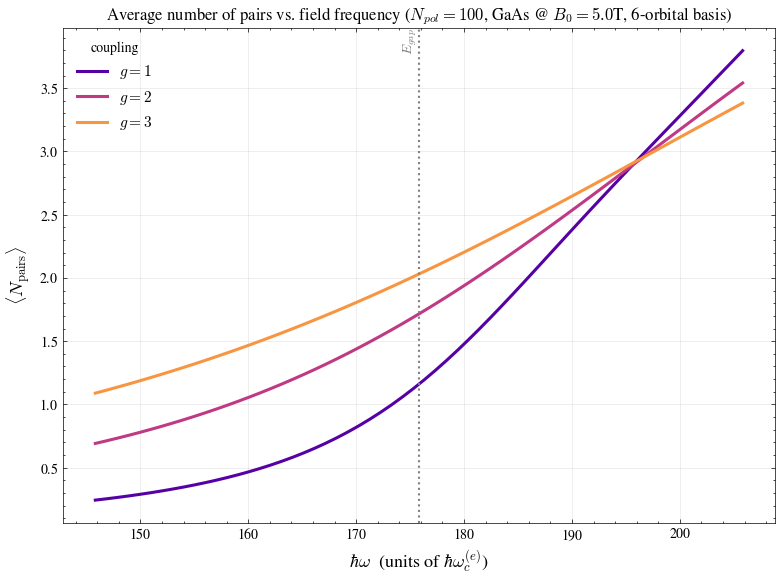

In [4]:
"""
average number of electron-hole pairs <N_pairs>
as a function of the field frequency hbar*omega, for fixed total polariton
number N_pol = N_pairs + N_ph = 100, comparing coupling strengths g=1,2,3

============================================================================
PHYSICAL PARAMETERS (illustrative GaAs quantum dot)
============================================================================
    m_e = 0.067 m0, m_h = 0.45 m0     (GaAs effective masses)
    g_e = -0.44, g_h = -2.0           (g-factors; g_h is a typical
                                        illustrative dot value)
    eps = 12.9                         (GaAs dielectric constant)
    E_gap = 1.519 eV                   (GaAs band gap, low T)
    B0 = 5 Tesla                       (illustrative magnetic field)

============================================================================
BASIS TRUNCATION
============================================================================
6 orbitals: Landau levels n=0,1, angular momentum l=-1,0,1 (need >=2 Landau
levels to engage the off-diagonal <i|r^2|j> term in T_ij; a single level
n=0 makes T purely diagonal)
============================================================================
"""
import itertools
import time
import pickle
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh
from scipy.special import eval_genlaguerre, gammaln
import matplotlib.pyplot as plt

# ============================================================================
# 1. Physical parameters (illustrative GaAs quantum dot, B0 = 5 T)
# ============================================================================

E_CHARGE = 4.803204e-10
C_LIGHT = 2.99792458e10
HBAR = 1.054571817e-27
M0 = 9.1093837015e-28
EV_TO_ERG = 1.602176634e-12
MU_BOHR = 9.2740100783e-21

M_E = 0.067 * M0
M_H = 0.45 * M0
G_E = -0.44
G_H = -2.0
EPS = 12.9
E_GAP_EV = 1.519
E_GAP = E_GAP_EV * EV_TO_ERG
B0_TESLA = 5.0
B0_GAUSS = B0_TESLA * 1e4

OMEGA_C_E = E_CHARGE * B0_GAUSS / (M_E * C_LIGHT)
OMEGA_C_H = E_CHARGE * B0_GAUSS / (M_H * C_LIGHT)
L_B = np.sqrt(2 * HBAR * C_LIGHT / (E_CHARGE * B0_GAUSS))
BETA_PHYSICAL = E_CHARGE**2 / (EPS * L_B)

ENERGY_UNIT = HBAR * OMEGA_C_E

def to_units(erg_value):
    return erg_value / ENERGY_UNIT

HBAR_OMEGA_C_E = 1.0
HBAR_OMEGA_C_H = to_units(HBAR * OMEGA_C_H)
BETA = to_units(BETA_PHYSICAL)
E_GAP_DIMLESS = to_units(E_GAP)
ZEEMAN_E = to_units(G_E * MU_BOHR * B0_GAUSS)
ZEEMAN_H = to_units(G_H * MU_BOHR * B0_GAUSS)

OMEGA_0_DIMLESS = 1.0
SPIN_E = -0.5
SPIN_H = +0.5


# ============================================================================
# 2. Fock-Darwin radial functions and Landau-level energies
# ============================================================================

def fd_radial(n, l, x):
    absl = abs(l)
    log_norm = 0.5 * (gammaln(n + 1) - np.log(np.pi) - gammaln(n + absl + 1))
    norm = np.exp(log_norm)
    return norm * x**absl * eval_genlaguerre(n, absl, x**2) * np.exp(-x**2 / 2.0)

def landau_energy(n, l, species):
    if species == 'e':
        omega_c = HBAR_OMEGA_C_E
        sign_l = +1
        zeeman = ZEEMAN_E * SPIN_E
        gap = E_GAP_DIMLESS
    elif species == 'h':
        omega_c = HBAR_OMEGA_C_H
        sign_l = -1
        zeeman = -ZEEMAN_H * SPIN_H
        gap = 0.0
    else:
        raise ValueError("species must be 'e' or 'h'")
    level = omega_c * (2*n + abs(l) + sign_l*l + 1) / 2.0
    return level + zeeman + gap

def r2_matrix_element(ni, li, nj, lj):
    if li != lj:
        return 0.0
    absl = abs(li)
    val = 0.0
    if ni == nj:
        val += (2*ni + absl + 1)
    if ni - 1 == nj:
        val += -np.sqrt(ni * (ni + absl))
    if ni + 1 == nj:
        val += -np.sqrt((ni+1) * (ni + absl + 1))
    return val

def build_T_matrix(orbitals, species):
    n_orb = len(orbitals)
    omega_c = HBAR_OMEGA_C_E if species == 'e' else HBAR_OMEGA_C_H
    T = np.zeros((n_orb, n_orb))
    for i, (ni, li) in enumerate(orbitals):
        T[i, i] += landau_energy(ni, li, species)
    for i, (ni, li) in enumerate(orbitals):
        for j, (nj, lj) in enumerate(orbitals):
            r2 = r2_matrix_element(ni, li, nj, lj)
            if r2 != 0.0:
                T[i, j] += (OMEGA_0_DIMLESS**2) * r2 / omega_c
    return T

def build_orbital_list_landau(l_max=1, n_shells=2):
    orbitals = []
    for n in range(n_shells):
        for l in range(-l_max, l_max + 1):
            orbitals.append((n, l))
    return orbitals


# ============================================================================
# 3. Coulomb matrix elements <r,s|1/r|u,v>  (eq. 4.11) via FFT real-space method
# ============================================================================

def phi_grid(n_, l_, X, Y):
    R = np.hypot(X, Y)
    TH = np.arctan2(Y, X)
    return fd_radial(n_, l_, R) * np.exp(1j * l_ * TH)

def coulomb_kernel_fft(n, dx):
    N = 2 * n
    xs = (np.arange(N) - N // 2) * dx
    X, Y = np.meshgrid(xs, xs, indexing='ij')
    R = np.hypot(X, Y)
    kernel = np.zeros_like(R)
    nz = R > 1e-12
    kernel[nz] = 1.0 / R[nz]
    a_eff = dx / np.sqrt(np.pi)
    kernel[N // 2, N // 2] = 2.0 / a_eff
    return kernel, N

def coulomb_element_grid(state_r, state_s, state_u, state_v, L=9.0, n=200):
    nr, lr = state_r; ns, ls_ = state_s; nu_, lu = state_u; nv, lv = state_v
    if (lr + ls_) != (lu + lv):
        return 0.0
    xs = np.linspace(-L, L, n, endpoint=False)
    dx = xs[1] - xs[0]
    X, Y = np.meshgrid(xs, xs, indexing='ij')

    phi_r = phi_grid(nr, lr, X, Y)
    phi_s = phi_grid(ns, ls_, X, Y)
    phi_u = phi_grid(nu_, lu, X, Y)
    phi_v = phi_grid(nv, lv, X, Y)

    rho_ru = np.conj(phi_r) * phi_u
    rho_sv = np.conj(phi_s) * phi_v

    kernel, N = coulomb_kernel_fft(n, dx)
    pad = (N - n) // 2
    rho_sv_padded = np.zeros((N, N), dtype=complex)
    rho_sv_padded[pad:pad + n, pad:pad + n] = rho_sv

    F_rho = np.fft.fft2(rho_sv_padded)
    F_ker = np.fft.fft2(np.fft.ifftshift(kernel))
    V_padded = (np.fft.ifft2(F_rho * F_ker) * dx**2).real
    V = V_padded[pad:pad + n, pad:pad + n]

    return float(np.sum(rho_ru * V).real * dx**2)


# ============================================================================
# 4. Many-body basis (Slater determinants as bitmasks), restricted to L=0
# ============================================================================

def enumerate_configs(orbitals, n_particles):
    n_orb = len(orbitals)
    if n_particles == 0:
        return [(0, 0)]
    if n_particles > n_orb:
        return []
    configs = []
    for occ in itertools.combinations(range(n_orb), n_particles):
        bitmask, totL = 0, 0
        for idx in occ:
            n_, l_ = orbitals[idx]
            bitmask |= (1 << idx)
            totL += l_
        configs.append((bitmask, totL))
    return configs

def bitmask_to_occ(bitmask, n_orb):
    return [i for i in range(n_orb) if (bitmask >> i) & 1]


# ============================================================================
# 5. Fermionic sign tracking
# ============================================================================

def popcount_below(bitmask, idx):
    return bin(bitmask & ((1 << idx) - 1)).count("1")

def apply_annihilate(bitmask, idx):
    if not (bitmask >> idx) & 1:
        return None, 0
    sign = (-1) ** popcount_below(bitmask, idx)
    return bitmask & ~(1 << idx), sign

def apply_create(bitmask, idx):
    if (bitmask >> idx) & 1:
        return None, 0
    sign = (-1) ** popcount_below(bitmask, idx)
    return bitmask | (1 << idx), sign

def one_body_action(mask, i, j):
    m, sign = apply_annihilate(mask, j)
    if m is None: return None, 0
    m, sg = apply_create(m, i); sign *= sg
    if m is None: return None, 0
    return m, sign

def two_body_action(mask, r, s, u, v):
    m, sign = apply_annihilate(mask, u)
    if m is None: return None, 0
    m, sg = apply_annihilate(m, v); sign *= sg
    if m is None: return None, 0
    m, sg = apply_create(m, s); sign *= sg
    if m is None: return None, 0
    m, sg = apply_create(m, r); sign *= sg
    if m is None: return None, 0
    return m, sign


# ============================================================================
# 6. Photon-free e-h Hamiltonian for a fixed N_pairs sector (full T_ij + Coulomb)
# ============================================================================

def build_eh_hamiltonian(N_pairs, orbitals, coulomb_of, T_e, T_h, beta):
    n_orb = len(orbitals)
    e_configs = enumerate_configs(orbitals, N_pairs)
    h_configs = enumerate_configs(orbitals, N_pairs)
    states = [(be, bh) for (be, Le) in e_configs for (bh, Lh) in h_configs if Le + Lh == 0]
    idx_of = {s: i for i, s in enumerate(states)}
    dim = len(states)
    H = lil_matrix((dim, dim))

    nz_e = np.argwhere(np.abs(T_e) > 1e-14)
    nz_h = np.argwhere(np.abs(T_h) > 1e-14)

    for col, (em, hm) in enumerate(states):
        for (i, j) in nz_e:
            i, j = int(i), int(j)
            if not (em >> j) & 1:
                continue
            new_em, sign = one_body_action(em, i, j)
            if new_em is None:
                continue
            new_state = (new_em, hm)
            if new_state not in idx_of:
                continue
            H[idx_of[new_state], col] += T_e[i, j] * sign
        for (i, j) in nz_h:
            i, j = int(i), int(j)
            if not (hm >> j) & 1:
                continue
            new_hm, sign = one_body_action(hm, i, j)
            if new_hm is None:
                continue
            new_state = (em, new_hm)
            if new_state not in idx_of:
                continue
            H[idx_of[new_state], col] += T_h[i, j] * sign

    for species_idx in (0, 1):
        for i, pair in enumerate(states):
            mask = pair[species_idx]
            occ = bitmask_to_occ(mask, n_orb)
            if len(occ) < 2:
                continue
            for u in occ:
                for v in occ:
                    if u == v:
                        continue
                    for r in range(n_orb):
                        for s in range(n_orb):
                            if r == s:
                                continue
                            val = coulomb_of(r, s, u, v)
                            if val == 0.0:
                                continue
                            new_mask, sign = two_body_action(mask, r, s, u, v)
                            if new_mask is None:
                                continue
                            new_pair = (new_mask, pair[1]) if species_idx == 0 else (pair[0], new_mask)
                            if new_pair not in idx_of:
                                continue
                            H[idx_of[new_pair], i] += 0.5 * beta * val * sign

    for i, (em, hm) in enumerate(states):
        e_occ = bitmask_to_occ(em, n_orb)
        h_occ = bitmask_to_occ(hm, n_orb)
        for u in e_occ:
            for v in h_occ:
                for r in range(n_orb):
                    for s in range(n_orb):
                        val = coulomb_of(r, s, u, v)
                        if val == 0.0:
                            continue
                        new_em, sign_e = apply_annihilate(em, u)
                        if new_em is None: continue
                        new_em, sg = apply_create(new_em, r); sign_e *= sg
                        if new_em is None: continue
                        new_hm, sign_h = apply_annihilate(hm, v)
                        if new_hm is None: continue
                        new_hm, sg = apply_create(new_hm, s); sign_h *= sg
                        if new_hm is None: continue
                        new_pair = (new_em, new_hm)
                        if new_pair not in idx_of:
                            continue
                        H[idx_of[new_pair], i] += -beta * val * sign_e * sign_h

    return H.tocsr(), states


# ============================================================================
# 7. Conjugate-orbital map + fixed-N_pol polariton Hamiltonian
# ============================================================================

def build_conjugate_map(orbitals):
    conj = {}
    for i, (ni, li) in enumerate(orbitals):
        for j, (nj, lj) in enumerate(orbitals):
            if nj == ni and lj == -li:
                conj[i] = j
                break
    return conj

def precompute_sectors(N_pol, orbitals, coulomb_of, T_e, T_h, beta):
    n_orb = len(orbitals)
    CONJ = build_conjugate_map(orbitals)
    max_pairs = min(N_pol, n_orb)

    sector_H, sector_states = {}, {}
    for N_pairs in range(max_pairs + 1):
        H_eh, states = build_eh_hamiltonian(N_pairs, orbitals, coulomb_of, T_e, T_h, beta)
        sector_H[N_pairs] = H_eh
        sector_states[N_pairs] = states

    offsets, off = {}, 0
    for N_pairs in range(max_pairs + 1):
        offsets[N_pairs] = off
        off += len(sector_states[N_pairs])
    dim_total = off

    coupling_terms = []
    for N_pairs in range(max_pairs):
        states_lo = sector_states[N_pairs]
        states_hi = sector_states[N_pairs + 1]
        idx_hi = {s: i for i, s in enumerate(states_hi)}
        for i, (em, hm) in enumerate(states_lo):
            for n in range(n_orb):
                nbar = CONJ[n]
                if (em >> n) & 1:
                    continue
                if (hm >> nbar) & 1:
                    continue
                new_em, sign_e = apply_create(em, n)
                if new_em is None:
                    continue
                new_hm, sign_h = apply_create(hm, nbar)
                if new_hm is None:
                    continue
                new_state = (new_em, new_hm)
                if new_state not in idx_hi:
                    continue
                j = idx_hi[new_state]
                coupling_terms.append((N_pairs, i, j, sign_e * sign_h))

    return {
        "max_pairs": max_pairs, "sector_H": sector_H, "sector_states": sector_states,
        "offsets": offsets, "dim_total": dim_total, "coupling_terms": coupling_terms,
    }

def assemble_Npol_hamiltonian(precomp, N_pol, E_gap_photon, hbar_omega, g):
    max_pairs = precomp["max_pairs"]
    sector_H = precomp["sector_H"]
    sector_states = precomp["sector_states"]
    offsets = precomp["offsets"]
    dim_total = precomp["dim_total"]

    H = lil_matrix((dim_total, dim_total))

    for N_pairs in range(max_pairs + 1):
        N_ph = N_pol - N_pairs
        off = offsets[N_pairs]
        dim_block = len(sector_states[N_pairs])
        H[off:off+dim_block, off:off+dim_block] += sector_H[N_pairs]
        photon_E = (E_gap_photon + hbar_omega) * N_ph
        for i in range(dim_block):
            H[off+i, off+i] += photon_E

    for (N_pairs, i, j, sign) in precomp["coupling_terms"]:
        N_ph_lo = N_pol - N_pairs
        photon_factor = np.sqrt(N_ph_lo)
        off_lo = offsets[N_pairs]
        off_hi = offsets[N_pairs + 1]
        val = g * photon_factor * sign
        H[off_hi + j, off_lo + i] += val
        H[off_lo + i, off_hi + j] += val

    return H.tocsr(), offsets, sector_states, max_pairs

def ground_state_Npairs_expectation(precomp, N_pol, E_gap_photon, hbar_omega, g):
    H, offsets, sector_states, max_pairs = assemble_Npol_hamiltonian(
        precomp, N_pol, E_gap_photon, hbar_omega, g)
    dim = H.shape[0]
    if dim <= 50:
        evals, evecs = np.linalg.eigh(H.toarray())
    else:
        evals, evecs = eigsh(H, k=1, which='SA')
    gs = evecs[:, 0]
    N_pairs_exp = 0.0
    for N_pairs in range(max_pairs + 1):
        off = offsets[N_pairs]
        dim_block = len(sector_states[N_pairs])
        prob = np.sum(np.abs(gs[off:off+dim_block])**2)
        N_pairs_exp += N_pairs * prob
    return N_pairs_exp


# ============================================================================
# 8. Main driver
# ============================================================================

def main():
    L_MAX, N_SHELLS = 1, 2        # 6 orbitals: n=0,1, l=-1,0,1
    N_POL = 100                    # fixed total polariton number (per the text)
    E_GAP_PHOTON = 0.0              # E_gap already appears in the electron energy;
                                     # NOT double-counted again here in the photon term
                                     # beyond what's needed -- see docstring note.
    G_VALUES = [1.0, 2.0, 3.0]
    GRID_L, GRID_N = 9.0, 200

    orbitals = build_orbital_list_landau(L_MAX, N_SHELLS)
    n_orb = len(orbitals)
    print(f"Basis: {n_orb} Landau-level orbitals (n,l): {orbitals}")
    print(f"\nPhysical parameters (illustrative GaAs dot, B0={B0_TESLA} T):")
    print(f"  hbar*omega_c^(e) = {HBAR*OMEGA_C_E/EV_TO_ERG*1000:.4f} meV  (energy unit)")
    print(f"  hbar*omega_c^(h) = {HBAR*OMEGA_C_H/EV_TO_ERG*1000:.4f} meV  -> {HBAR_OMEGA_C_H:.5f} (dimensionless)")
    print(f"  beta             = {BETA_PHYSICAL/EV_TO_ERG*1000:.4f} meV  -> {BETA:.5f} (dimensionless)")
    print(f"  E_gap            = {E_GAP_EV:.4f} eV      -> {E_GAP_DIMLESS:.3f} (dimensionless)")

    T_e = build_T_matrix(orbitals, 'e')
    T_h = build_T_matrix(orbitals, 'h')

    ls_ = [l for (n_, l) in orbitals]
    cache = {}
    t0 = time.time()
    for r in range(n_orb):
        for s in range(n_orb):
            for u in range(n_orb):
                for v in range(n_orb):
                    if ls_[r] + ls_[s] != ls_[u] + ls_[v]:
                        continue
                    key = min((r, s, u, v), (s, r, v, u))
                    if key in cache:
                        continue
                    cache[key] = coulomb_element_grid(
                        orbitals[key[0]], orbitals[key[1]], orbitals[key[2]], orbitals[key[3]],
                        L=GRID_L, n=GRID_N)
    print(f"\nPrecomputed {len(cache)} distinct Coulomb integrals in {time.time()-t0:.1f}s")

    def coulomb_of(r, s, u, v):
        if ls_[r] + ls_[s] != ls_[u] + ls_[v]:
            return 0.0
        return cache[min((r, s, u, v), (s, r, v, u))]

    t0 = time.time()
    precomp = precompute_sectors(N_POL, orbitals, coulomb_of, T_e, T_h, beta=BETA)
    print(f"Precomputed e-h Coulomb blocks for N_pairs=0..{precomp['max_pairs']} "
          f"in {time.time()-t0:.1f}s")

    H_test, *_ = assemble_Npol_hamiltonian(precomp, N_POL, E_GAP_PHOTON, E_GAP_DIMLESS, 1.0)
    Hd = H_test.toarray()
    herm_err = np.max(np.abs(Hd - Hd.T))
    print(f"Hermiticity check: max|H-H^T| = {herm_err:.2e}")

    # Sweep hbar_omega centered on E_gap (see docstring for why this is the
    # physically relevant window, not near zero)
    HBAR_OMEGA_LIST = np.linspace(E_GAP_DIMLESS - 30, E_GAP_DIMLESS + 30, 60)

    results = {g: [] for g in G_VALUES}
    t_start = time.time()
    for g in G_VALUES:
        t_g = time.time()
        for hbar_omega in HBAR_OMEGA_LIST:
            Nexp = ground_state_Npairs_expectation(precomp, N_POL, E_GAP_PHOTON, hbar_omega, g)
            results[g].append(Nexp)
        print(f"  g={g}: swept {len(HBAR_OMEGA_LIST)} points in {time.time()-t_g:.1f}s")
    print(f"Total sweep time: {time.time()-t_start:.1f}s")

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.plasma(np.linspace(0.15, 0.75, len(G_VALUES)))
    for color, g in zip(colors, G_VALUES):
        ax.plot(HBAR_OMEGA_LIST, results[g], lw=2.2, color=color, label=fr"$g={g:.0f}$")

    ax.axvline(E_GAP_DIMLESS, color='gray', ls=':', lw=1.5)
    ax.text(E_GAP_DIMLESS, ax.get_ylim()[1], r"$E_{gap}$", rotation=90,
            va='top', ha='right', color='gray', fontsize=10)

    ax.set_xlabel(r"$\hbar\omega$  (units of $\hbar\omega_c^{(e)}$)", fontsize=13)
    ax.set_ylabel(r"$\langle N_{\mathrm{pairs}} \rangle$", fontsize=13)
    ax.set_title(fr"Average number of pairs vs. field frequency "
                 fr"($N_{{pol}}={N_POL}$, GaAs @ $B_0={B0_TESLA}$T, {n_orb}-orbital basis)",
                 fontsize=12)
    ax.legend(fontsize=11, title="coupling")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("pairs_vs_omega_landau.pdf")
    print("\nSaved plot to pairs_vs_omega_landau.png")

    with open("results_landau.pkl", "wb") as f:
        pickle.dump({"hbar_omega": HBAR_OMEGA_LIST, "results": results,
                     "N_pol": N_POL, "g_values": G_VALUES,
                     "orbitals": orbitals, "E_gap": E_GAP_DIMLESS}, f)


if __name__ == "__main__":
    main()

# Anticrossing and state identification

Basis: 6 Landau-level orbitals (n,l): [(0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]
Precomputed 158 distinct Coulomb integrals in 10.5s

1-pair sector: dim=12, Hermiticity err=1.39e-17
Lowest 4 one-pair eigenenergies: [179.7843 184.123  185.5537 186.7243]
Coupling projections <psi_k|sum e^dag h^dag|0>: [-1.0501  0.0137  1.0666 -0.8782]

5x5 Hamiltonian Hermitian: True

Saved anticrossing.png
Saved state_identification.png


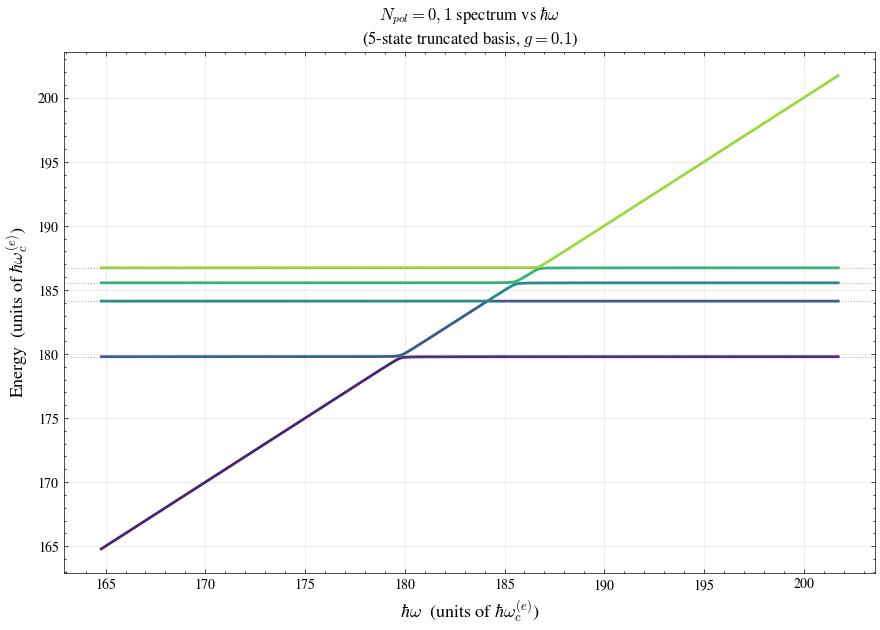

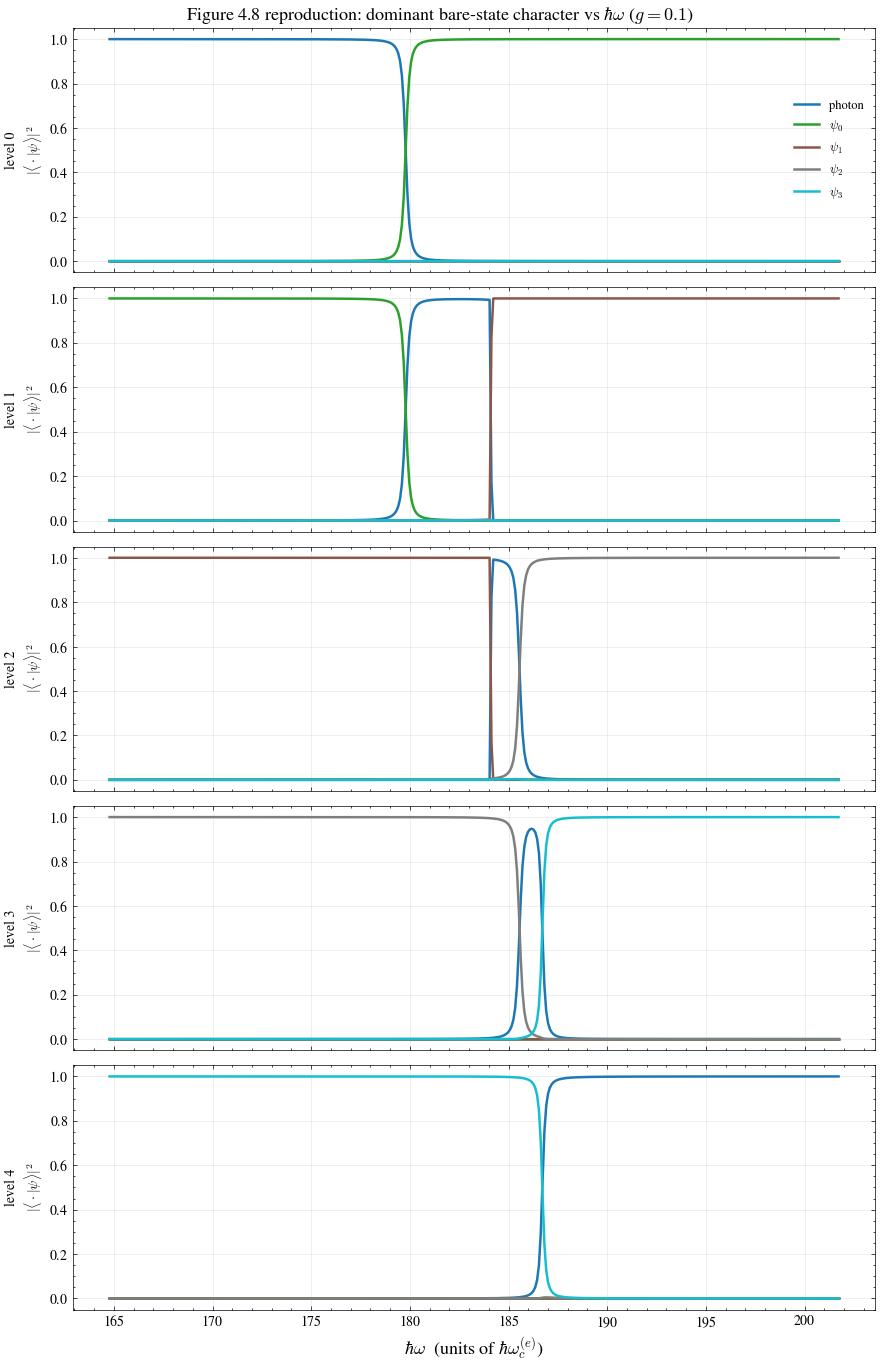

In [5]:
"""
The effect of the JC-model breakdown on
the anticrossing, using a basis truncated to 5 states (N_pol=0 or
1), for coupling g=1.

============================================================================
PHYSICS / MODEL
============================================================================
Basis (5 states, per the text):
    |0>            : 0 pairs, 1 photon  (N_pol = 1)
    |psi_0>...|psi_3>: the 4 LOWEST eigenstates of the N_pairs=1 many-body
                       Hamiltonian (photon-free e-h Coulomb problem, using
                       the correct Landau-level T_ij and beta = e^2/(eps l_B)
                       from the previous corrected calculation), each
                       tensored with 0 photons (also N_pol = 1).

Truncated 5x5 Hamiltonian:
    H[0,0]   = E_gap_photon + hbar*omega              (photon energy, N_ph=1)
    H[k+1,k+1] = E1[k]                                  (k-th one-pair eigenenergy)
    H[0,k+1] = H[k+1,0] = g * <psi_k| sum_n e_n^dag h_nbar^dag |0>
             (light-matter coupling matrix element, computed by projecting
              the pair-creation operator acting on the vacuum onto each of
              the 4 one-pair eigenstates)

Diagonalizing this 5x5 matrix as a function of hbar*omega gives Figure 4.7:
the lowest curve reduces EXACTLY to the ordinary two-level Jaynes-Cummings
anticrossing (photon <-> lowest-energy pair state psi_0), with resonance at
hbar*omega = E_gap + E1[0] (E1[0] being "the energy of the base state of 1
pair obtained before"). As hbar*omega is increased further, the SAME photon
character "hops" into resonance with each successive excited pair state
psi_1, psi_2, psi_3 in turn, producing one additional anticrossing per
excited level -- until the highest level is reached, where the ordinary JC
form is recovered again (now between the photon and psi_3).

Figure 4.8 identifies, for each of the 5 dressed eigenstates and each
hbar*omega, which bare state (photon or psi_0..psi_3) it is dominantly built
from, via the overlap (inner product) |<bare|dressed>|^2. This produces the
clean "hopping" pattern described in the text.
============================================================================
"""
import itertools
import pickle
import time
import numpy as np
from scipy.sparse import lil_matrix
from scipy.special import eval_genlaguerre, gammaln
import matplotlib.pyplot as plt

# ============================================================================
# 1. Physical parameters (illustrative GaAs quantum dot, B0 = 5 T)
#    -- identical to the corrected multiexciton_spectrum_landau.py /
#    fig_4_6_pairs_vs_omega_landau.py used previously
# ============================================================================

E_CHARGE = 4.803204e-10
C_LIGHT = 2.99792458e10
HBAR = 1.054571817e-27
M0 = 9.1093837015e-28
EV_TO_ERG = 1.602176634e-12
MU_BOHR = 9.2740100783e-21

M_E = 0.067 * M0
M_H = 0.45 * M0
G_E = -0.44
G_H = -2.0
EPS = 12.9
E_GAP_EV = 1.519
E_GAP = E_GAP_EV * EV_TO_ERG
B0_TESLA = 5.0
B0_GAUSS = B0_TESLA * 1e4

OMEGA_C_E = E_CHARGE * B0_GAUSS / (M_E * C_LIGHT)
OMEGA_C_H = E_CHARGE * B0_GAUSS / (M_H * C_LIGHT)
L_B = np.sqrt(2 * HBAR * C_LIGHT / (E_CHARGE * B0_GAUSS))
BETA_PHYSICAL = E_CHARGE**2 / (EPS * L_B)
ENERGY_UNIT = HBAR * OMEGA_C_E

def to_units(erg_value):
    return erg_value / ENERGY_UNIT

HBAR_OMEGA_C_E = 1.0
HBAR_OMEGA_C_H = to_units(HBAR * OMEGA_C_H)
BETA = to_units(BETA_PHYSICAL)
E_GAP_DIMLESS = to_units(E_GAP)
ZEEMAN_E = to_units(G_E * MU_BOHR * B0_GAUSS)
ZEEMAN_H = to_units(G_H * MU_BOHR * B0_GAUSS)
OMEGA_0_DIMLESS = 1.0
SPIN_E = -0.5
SPIN_H = +0.5


# ============================================================================
# 2. Fock-Darwin radial functions, Landau energies, orbital basis
# ============================================================================

def fd_radial(n, l, x):
    absl = abs(l)
    log_norm = 0.5 * (gammaln(n + 1) - np.log(np.pi) - gammaln(n + absl + 1))
    norm = np.exp(log_norm)
    return norm * x**absl * eval_genlaguerre(n, absl, x**2) * np.exp(-x**2 / 2.0)

def landau_energy(n, l, species):
    if species == 'e':
        omega_c = HBAR_OMEGA_C_E; sign_l = +1
        zeeman = ZEEMAN_E * SPIN_E; gap = E_GAP_DIMLESS
    else:
        omega_c = HBAR_OMEGA_C_H; sign_l = -1
        zeeman = -ZEEMAN_H * SPIN_H; gap = 0.0
    level = omega_c * (2*n + abs(l) + sign_l*l + 1) / 2.0
    return level + zeeman + gap

def r2_matrix_element(ni, li, nj, lj):
    if li != lj:
        return 0.0
    absl = abs(li)
    val = 0.0
    if ni == nj: val += (2*ni + absl + 1)
    if ni - 1 == nj: val += -np.sqrt(ni * (ni + absl))
    if ni + 1 == nj: val += -np.sqrt((ni+1) * (ni + absl + 1))
    return val

def build_T_matrix(orbitals, species):
    n_orb = len(orbitals)
    omega_c = HBAR_OMEGA_C_E if species == 'e' else HBAR_OMEGA_C_H
    T = np.zeros((n_orb, n_orb))
    for i, (ni, li) in enumerate(orbitals):
        T[i, i] += landau_energy(ni, li, species)
    for i, (ni, li) in enumerate(orbitals):
        for j, (nj, lj) in enumerate(orbitals):
            r2 = r2_matrix_element(ni, li, nj, lj)
            if r2 != 0.0:
                T[i, j] += (OMEGA_0_DIMLESS**2) * r2 / omega_c
    return T

def build_orbital_list_landau(l_max=1, n_shells=2):
    return [(n, l) for n in range(n_shells) for l in range(-l_max, l_max + 1)]


# ============================================================================
# 3. Coulomb matrix elements (validated FFT real-space method, unchanged)
# ============================================================================

def phi_grid(n_, l_, X, Y):
    R = np.hypot(X, Y); TH = np.arctan2(Y, X)
    return fd_radial(n_, l_, R) * np.exp(1j * l_ * TH)

def coulomb_kernel_fft(n, dx):
    N = 2 * n
    xs = (np.arange(N) - N // 2) * dx
    X, Y = np.meshgrid(xs, xs, indexing='ij')
    R = np.hypot(X, Y)
    kernel = np.zeros_like(R)
    nz = R > 1e-12
    kernel[nz] = 1.0 / R[nz]
    a_eff = dx / np.sqrt(np.pi)
    kernel[N // 2, N // 2] = 2.0 / a_eff
    return kernel, N

def coulomb_element_grid(state_r, state_s, state_u, state_v, L=9.0, n=200):
    nr, lr = state_r; ns, ls_ = state_s; nu_, lu = state_u; nv, lv = state_v
    if (lr + ls_) != (lu + lv):
        return 0.0
    xs = np.linspace(-L, L, n, endpoint=False)
    dx = xs[1] - xs[0]
    X, Y = np.meshgrid(xs, xs, indexing='ij')
    phi_r = phi_grid(nr, lr, X, Y); phi_s = phi_grid(ns, ls_, X, Y)
    phi_u = phi_grid(nu_, lu, X, Y); phi_v = phi_grid(nv, lv, X, Y)
    rho_ru = np.conj(phi_r) * phi_u
    rho_sv = np.conj(phi_s) * phi_v
    kernel, N = coulomb_kernel_fft(n, dx)
    pad = (N - n) // 2
    rho_sv_padded = np.zeros((N, N), dtype=complex)
    rho_sv_padded[pad:pad + n, pad:pad + n] = rho_sv
    F_rho = np.fft.fft2(rho_sv_padded)
    F_ker = np.fft.fft2(np.fft.ifftshift(kernel))
    V_padded = (np.fft.ifft2(F_rho * F_ker) * dx**2).real
    V = V_padded[pad:pad + n, pad:pad + n]
    return float(np.sum(rho_ru * V).real * dx**2)


# ============================================================================
# 4. Many-body basis, fermionic sign tracking, one/two-body operator actions
# ============================================================================

def enumerate_configs(orbitals, n_particles):
    n_orb = len(orbitals)
    if n_particles == 0:
        return [(0, 0)]
    if n_particles > n_orb:
        return []
    configs = []
    for occ in itertools.combinations(range(n_orb), n_particles):
        bitmask, totL = 0, 0
        for idx in occ:
            n_, l_ = orbitals[idx]
            bitmask |= (1 << idx); totL += l_
        configs.append((bitmask, totL))
    return configs

def bitmask_to_occ(bitmask, n_orb):
    return [i for i in range(n_orb) if (bitmask >> i) & 1]

def popcount_below(bitmask, idx):
    return bin(bitmask & ((1 << idx) - 1)).count("1")

def apply_annihilate(bitmask, idx):
    if not (bitmask >> idx) & 1:
        return None, 0
    sign = (-1) ** popcount_below(bitmask, idx)
    return bitmask & ~(1 << idx), sign

def apply_create(bitmask, idx):
    if (bitmask >> idx) & 1:
        return None, 0
    sign = (-1) ** popcount_below(bitmask, idx)
    return bitmask | (1 << idx), sign

def one_body_action(mask, i, j):
    m, sign = apply_annihilate(mask, j)
    if m is None: return None, 0
    m, sg = apply_create(m, i); sign *= sg
    if m is None: return None, 0
    return m, sign

def two_body_action(mask, r, s, u, v):
    m, sign = apply_annihilate(mask, u)
    if m is None: return None, 0
    m, sg = apply_annihilate(m, v); sign *= sg
    if m is None: return None, 0
    m, sg = apply_create(m, s); sign *= sg
    if m is None: return None, 0
    m, sg = apply_create(m, r); sign *= sg
    if m is None: return None, 0
    return m, sign


# ============================================================================
# 5. Many-body Hamiltonian for the N_pairs=1 sector (full T_ij + Coulomb)
# ============================================================================

def build_eh_hamiltonian(N_pairs, orbitals, coulomb_of, T_e, T_h, beta):
    n_orb = len(orbitals)
    e_configs = enumerate_configs(orbitals, N_pairs)
    h_configs = enumerate_configs(orbitals, N_pairs)
    states = [(be, bh) for (be, Le) in e_configs for (bh, Lh) in h_configs if Le + Lh == 0]
    idx_of = {s: i for i, s in enumerate(states)}
    dim = len(states)
    H = lil_matrix((dim, dim))

    nz_e = np.argwhere(np.abs(T_e) > 1e-14)
    nz_h = np.argwhere(np.abs(T_h) > 1e-14)

    for col, (em, hm) in enumerate(states):
        for (i, j) in nz_e:
            i, j = int(i), int(j)
            if not (em >> j) & 1: continue
            new_em, sign = one_body_action(em, i, j)
            if new_em is None: continue
            new_state = (new_em, hm)
            if new_state not in idx_of: continue
            H[idx_of[new_state], col] += T_e[i, j] * sign
        for (i, j) in nz_h:
            i, j = int(i), int(j)
            if not (hm >> j) & 1: continue
            new_hm, sign = one_body_action(hm, i, j)
            if new_hm is None: continue
            new_state = (em, new_hm)
            if new_state not in idx_of: continue
            H[idx_of[new_state], col] += T_h[i, j] * sign

    for species_idx in (0, 1):
        for i, pair in enumerate(states):
            mask = pair[species_idx]
            occ = bitmask_to_occ(mask, n_orb)
            if len(occ) < 2: continue
            for u in occ:
                for v in occ:
                    if u == v: continue
                    for r in range(n_orb):
                        for s in range(n_orb):
                            if r == s: continue
                            val = coulomb_of(r, s, u, v)
                            if val == 0.0: continue
                            new_mask, sign = two_body_action(mask, r, s, u, v)
                            if new_mask is None: continue
                            new_pair = (new_mask, pair[1]) if species_idx == 0 else (pair[0], new_mask)
                            if new_pair not in idx_of: continue
                            H[idx_of[new_pair], i] += 0.5 * beta * val * sign

    for i, (em, hm) in enumerate(states):
        e_occ = bitmask_to_occ(em, n_orb); h_occ = bitmask_to_occ(hm, n_orb)
        for u in e_occ:
            for v in h_occ:
                for r in range(n_orb):
                    for s in range(n_orb):
                        val = coulomb_of(r, s, u, v)
                        if val == 0.0: continue
                        new_em, sign_e = apply_annihilate(em, u)
                        if new_em is None: continue
                        new_em, sg = apply_create(new_em, r); sign_e *= sg
                        if new_em is None: continue
                        new_hm, sign_h = apply_annihilate(hm, v)
                        if new_hm is None: continue
                        new_hm, sg = apply_create(new_hm, s); sign_h *= sg
                        if new_hm is None: continue
                        new_pair = (new_em, new_hm)
                        if new_pair not in idx_of: continue
                        H[idx_of[new_pair], i] += -beta * val * sign_e * sign_h

    return H.tocsr(), states


def build_conjugate_map(orbitals):
    conj = {}
    for i, (ni, li) in enumerate(orbitals):
        for j, (nj, lj) in enumerate(orbitals):
            if nj == ni and lj == -li:
                conj[i] = j
                break
    return conj


# ============================================================================
# 6. Main driver
# ============================================================================

def main():
    L_MAX, N_SHELLS = 1, 2
    N_KEEP = 4           # keep 4 lowest one-pair eigenstates (+1 photon state = 5 total)
    G = .1
    E_GAP_PHOTON = 0.0   # E_gap already lives in the electron energy; see earlier notes
    GRID_L, GRID_N = 9.0, 200

    orbitals = build_orbital_list_landau(L_MAX, N_SHELLS)
    n_orb = len(orbitals)
    print(f"Basis: {n_orb} Landau-level orbitals (n,l): {orbitals}")

    T_e = build_T_matrix(orbitals, 'e')
    T_h = build_T_matrix(orbitals, 'h')

    ls_ = [l for (n_, l) in orbitals]
    cache = {}
    t0 = time.time()
    for r in range(n_orb):
        for s in range(n_orb):
            for u in range(n_orb):
                for v in range(n_orb):
                    if ls_[r] + ls_[s] != ls_[u] + ls_[v]:
                        continue
                    key = min((r, s, u, v), (s, r, v, u))
                    if key in cache:
                        continue
                    cache[key] = coulomb_element_grid(
                        orbitals[key[0]], orbitals[key[1]], orbitals[key[2]], orbitals[key[3]],
                        L=GRID_L, n=GRID_N)
    print(f"Precomputed {len(cache)} distinct Coulomb integrals in {time.time()-t0:.1f}s")

    def coulomb_of(r, s, u, v):
        if ls_[r] + ls_[s] != ls_[u] + ls_[v]:
            return 0.0
        return cache[min((r, s, u, v), (s, r, v, u))]

    # ---- diagonalize the N_pairs=1 sector, keep lowest N_KEEP eigenstates ----
    H1, states1 = build_eh_hamiltonian(1, orbitals, coulomb_of, T_e, T_h, beta=BETA)
    H1d = H1.toarray()
    print(f"\n1-pair sector: dim={H1d.shape[0]}, Hermiticity err={np.max(np.abs(H1d-H1d.T)):.2e}")
    evals1, evecs1 = np.linalg.eigh(H1d)
    E1 = evals1[:N_KEEP]
    V1 = evecs1[:, :N_KEEP]
    print(f"Lowest {N_KEEP} one-pair eigenenergies: {np.round(E1, 4)}")

    idx_of_1 = {s: i for i, s in enumerate(states1)}
    CONJ = build_conjugate_map(orbitals)

    # ---- coupling vector: w_i = <states1[i]| sum_n e_n^dag h_nbar^dag |vacuum> ----
    w = np.zeros(len(states1))
    for n in range(n_orb):
        nbar = CONJ[n]
        em, sign_e = apply_create(0, n)
        if em is None:
            continue
        hm, sign_h = apply_create(0, nbar)
        if hm is None:
            continue
        new_state = (em, hm)
        if new_state not in idx_of_1:
            continue
        w[idx_of_1[new_state]] += sign_e * sign_h

    coupling_to_level = V1.T @ w   # length-N_KEEP: <psi_k|sum e^dag h^dag|0>
    print(f"Coupling projections <psi_k|sum e^dag h^dag|0>: {np.round(coupling_to_level, 4)}")

    def build_H5(hbar_omega, g):
        dim = N_KEEP + 1
        H = np.zeros((dim, dim))
        H[0, 0] = E_GAP_PHOTON + hbar_omega
        for k in range(N_KEEP):
            H[k+1, k+1] = E1[k]
            val = g * coupling_to_level[k]
            H[0, k+1] += val
            H[k+1, 0] += val
        return H

    # sanity check
    H_test = build_H5(E_GAP_DIMLESS, G)
    print(f"\n5x5 Hamiltonian Hermitian: {np.allclose(H_test, H_test.T)}")

    # ---- sweep hbar_omega and diagonalize the 5x5 Hamiltonian ----
    hbar_omega_list = np.linspace(min(E1) - 15, max(E1) + 15, 400)
    n_hw = len(hbar_omega_list)
    all_evals = np.zeros((n_hw, N_KEEP + 1))
    overlaps = np.zeros((n_hw, N_KEEP + 1, N_KEEP + 1))

    for i, hw in enumerate(hbar_omega_list):
        H = build_H5(hw, G)
        evals, evecs = np.linalg.eigh(H)
        all_evals[i, :] = evals
        overlaps[i, :, :] = np.abs(evecs.T)**2

    # ---- Figure 4.7: anticrossing spectrum ----
    fig, ax = plt.subplots(figsize=(9, 6.5))
    colors = plt.cm.viridis(np.linspace(0.1, 0.85, N_KEEP + 1))
    for level in range(N_KEEP + 1):
        ax.plot(hbar_omega_list, all_evals[:, level], lw=2, color=colors[level])
    for Ek in E1:
        ax.axhline(Ek, color='gray', ls=':', lw=0.8, alpha=0.6)
    ax.set_xlabel(r"$\hbar\omega$  (units of $\hbar\omega_c^{(e)}$)", fontsize=13)
    ax.set_ylabel(r"Energy  (units of $\hbar\omega_c^{(e)}$)", fontsize=13)
    ax.set_title(f"$N_{{pol}}=0,1$ spectrum vs $\\hbar\\omega$"
                 f"\n(5-state truncated basis, $g={G:.1f}$)", fontsize=12)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("anticrossing.pdf")
    print("\nSaved anticrossing.png")

    # ---- Figure 4.8: state identification via inner product ----
    bare_labels = ["photon"] + [fr"$\psi_{k}$" for k in range(N_KEEP)]
    fig2, axes = plt.subplots(N_KEEP + 1, 1, figsize=(9, 14), sharex=True)
    tab_colors = plt.cm.tab10(np.linspace(0, 1, N_KEEP + 1))
    for dressed_level in range(N_KEEP + 1):
        ax = axes[dressed_level]
        for bare_idx in range(N_KEEP + 1):
            ax.plot(hbar_omega_list, overlaps[:, dressed_level, bare_idx],
                     color=tab_colors[bare_idx], lw=1.8,
                     label=bare_labels[bare_idx] if dressed_level == 0 else None)
        ax.set_ylabel(f"level {dressed_level}\n" + r"$|\langle \cdot|\psi\rangle|^2$", fontsize=10)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=9, loc="center right", ncol=1)
    axes[-1].set_xlabel(r"$\hbar\omega$  (units of $\hbar\omega_c^{(e)}$)", fontsize=13)
    fig2.suptitle(f"Figure 4.8 reproduction: dominant bare-state character vs "
                  f"$\\hbar\\omega$ ($g={G:.1f}$)", fontsize=13)
    fig2.tight_layout()
    fig2.savefig("state_identification.pdf")
    print("Saved state_identification.png")

    with open("results.pkl", "wb") as f:
        pickle.dump({"hbar_omega": hbar_omega_list, "all_evals": all_evals,
                     "overlaps": overlaps, "E1": E1, "g": G,
                     "coupling_to_level": coupling_to_level}, f)


if __name__ == "__main__":
    main()